# t-SNE Dimensionality Reduction

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a technique for visualizing high-dimensional data.
Unlike PCA which is linear, t-SNE is non-linear and does a much better job at separating clusters visually.

In this notebook, we'll apply t-SNE on the digits dataset and compare it with PCA to see the difference.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Loading the Dataset

We'll use the digits dataset — it has 1797 images of handwritten digits (0 to 9).
Each image is 8x8 = 64 pixels, so we have 64 features. Our goal is to compress this into 2D and visualize it.

In [12]:
digits = load_digits()

X = digits.data    # (1797, 64)
y = digits.target  # 0 to 9

print(f"Data shape: {X.shape}")
print(f"Labels: {np.unique(y)}")

Data shape: (1797, 64)
Labels: [0 1 2 3 4 5 6 7 8 9]


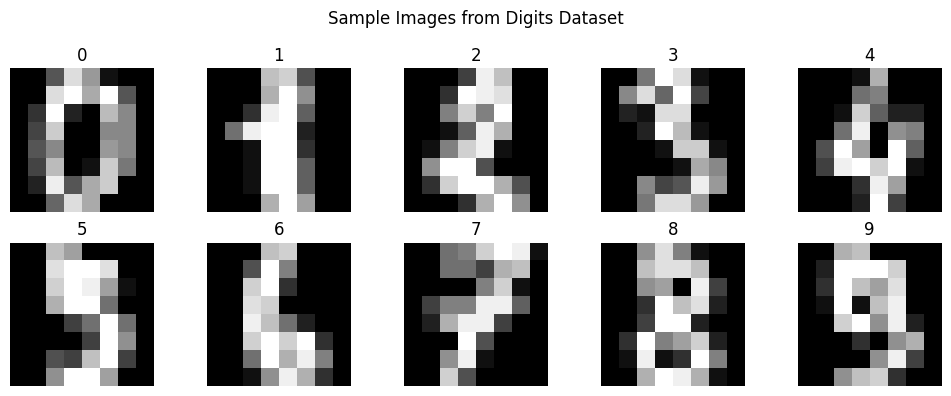

In [13]:
# let's quickly look at a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'{y[i]}')
    ax.axis('off')
plt.suptitle('Sample Images from Digits Dataset')
plt.tight_layout()
plt.show()

## Preprocessing

Before applying t-SNE, we standardize the data. This ensures all features are on the same scale.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

Mean: 0.0000, Std: 0.9763


## Applying t-SNE

Key parameters to know:
- `n_components` — output dimensions (we use 2 for 2D plot)
- `perplexity` — roughly how many neighbors each point considers. Usually between 5 and 50.
- `n_iter` — number of optimization steps
- `random_state` — for reproducibility

In [15]:
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE output shape: {X_tsne.shape}")

t-SNE output shape: (1797, 2)


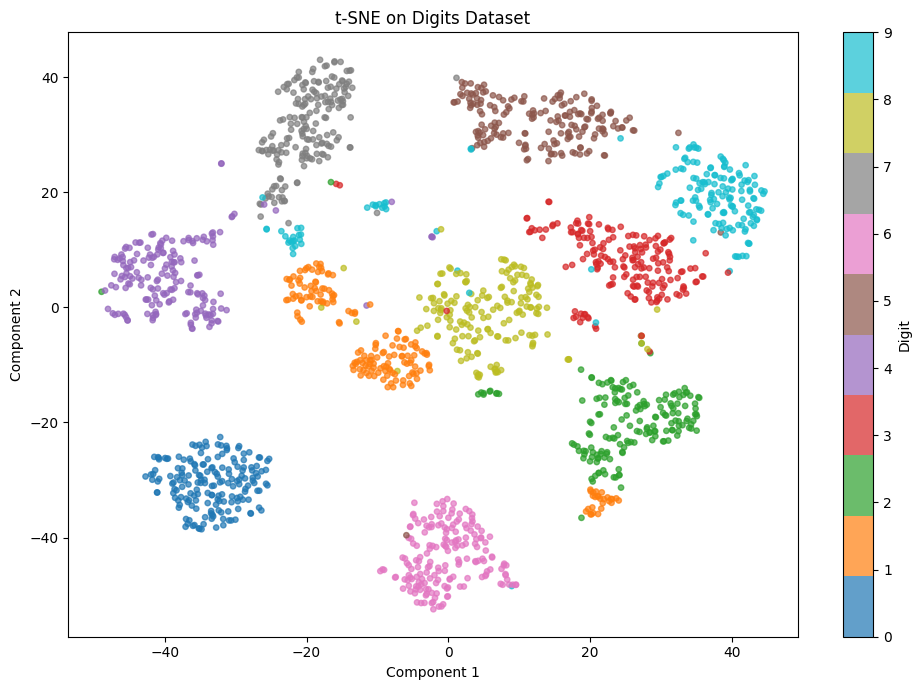

In [16]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, label='Digit')
plt.title('t-SNE on Digits Dataset')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

# each digit forms a pretty clean cluster — that's the power of t-SNE

## Comparing with PCA

PCA is a linear method. Let's see how well it separates the digits compared to t-SNE.

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Variance explained by 2 PCA components: 21.59%


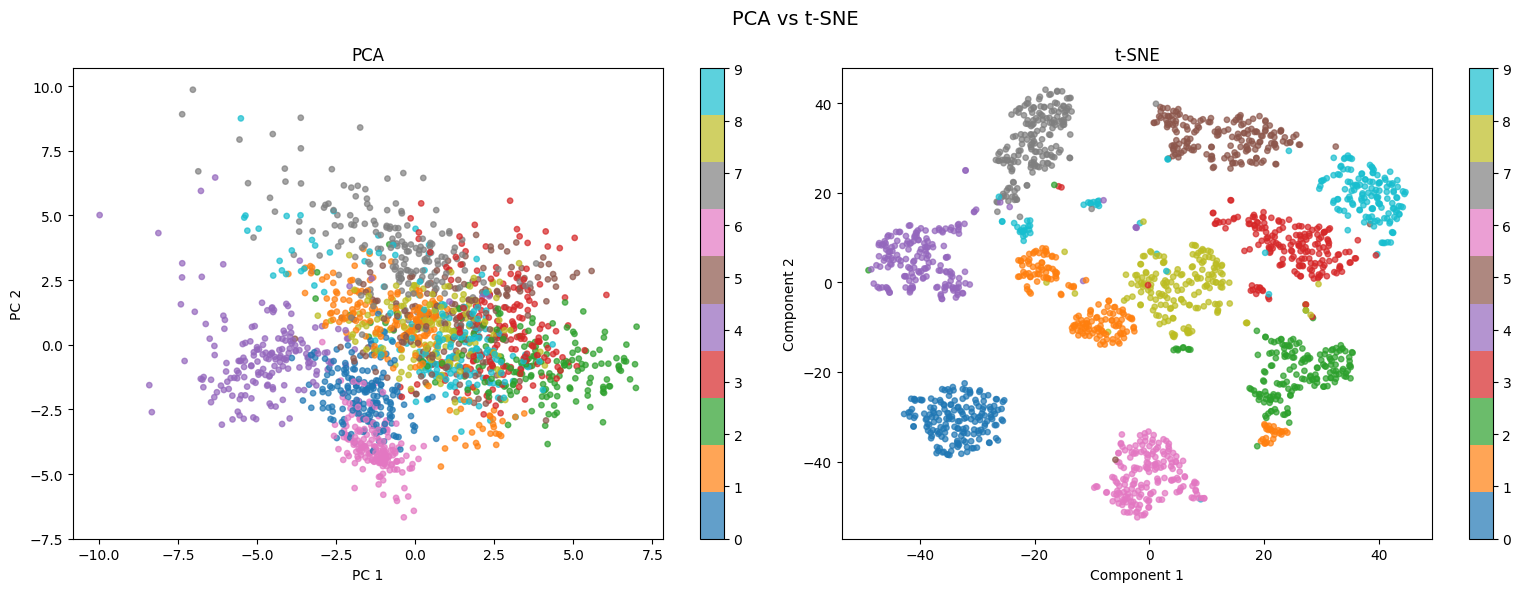

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
axes[0].set_title('PCA')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
plt.colorbar(sc2, ax=axes[1])

plt.suptitle('PCA vs t-SNE', fontsize=14)
plt.tight_layout()
plt.show()

# PCA overlaps a lot — t-SNE clusters are much cleaner

## Effect of Perplexity

Perplexity is the most sensitive hyperparameter in t-SNE. Let's see how the plot changes with different values.

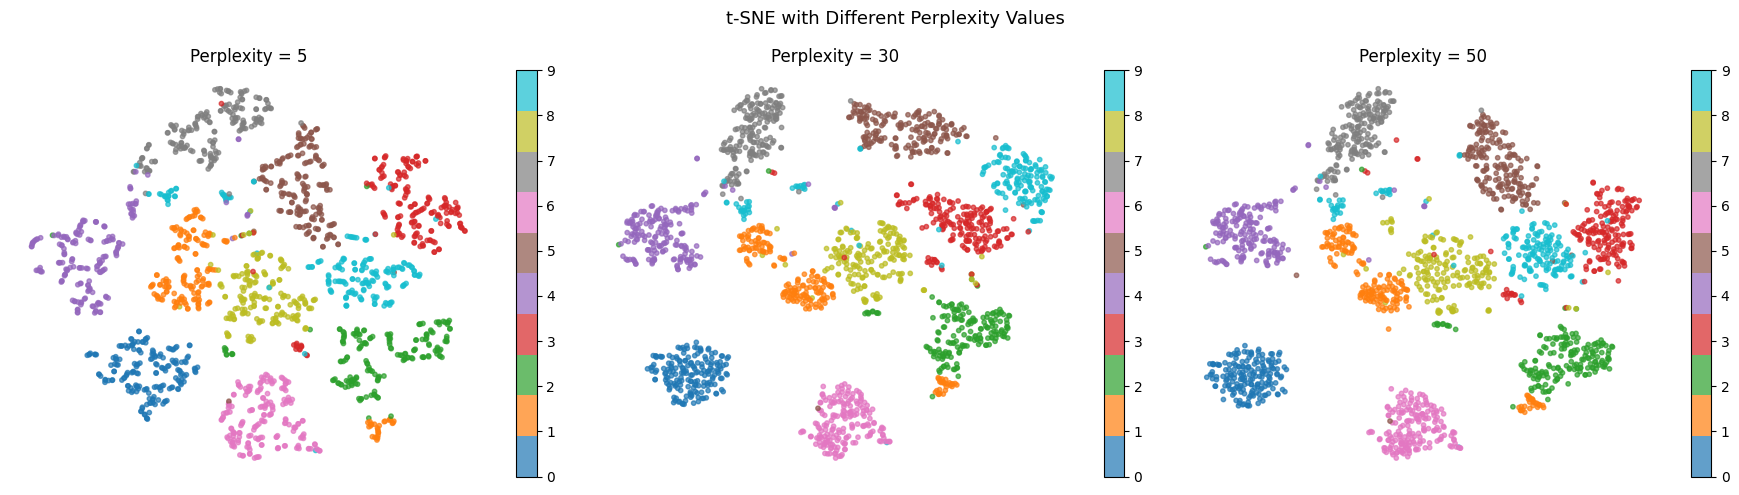

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate([5, 30, 50]):
    t = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
    X_t = t.fit_transform(X_scaled)
    sc = axes[i].scatter(X_t[:, 0], X_t[:, 1], c=y, cmap='tab10', alpha=0.7, s=10)
    axes[i].set_title(f'Perplexity = {perp}')
    axes[i].axis('off')
    plt.colorbar(sc, ax=axes[i])

plt.suptitle('t-SNE with Different Perplexity Values', fontsize=13)
plt.tight_layout()
plt.show()

## Recommended Pipeline for Large Datasets

For large datasets, running t-SNE directly on raw features is slow.
A common trick is to first reduce dimensions with PCA (say to 50), then apply t-SNE.
This speeds things up without losing much information.

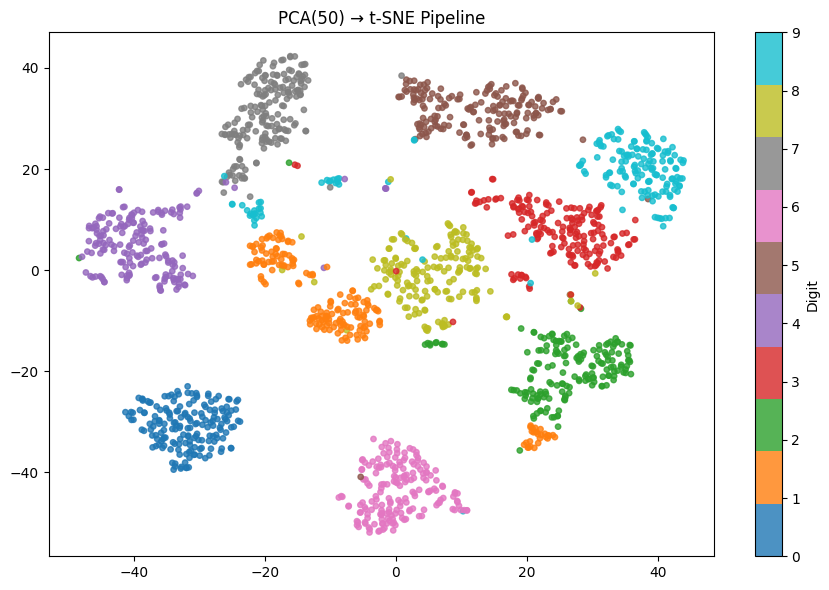

Clusters look clean and this ran faster than direct t-SNE on 64 features


In [20]:
# first reduce with PCA
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_scaled)

# then apply t-SNE
tsne2 = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_final = tsne2.fit_transform(X_pca50)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_final[:, 0], X_final[:, 1], c=y, cmap='tab10', alpha=0.8, s=15)
plt.colorbar(scatter, label='Digit')
plt.title('PCA(50) → t-SNE Pipeline')
plt.tight_layout()
plt.show()

print("Clusters look clean and this ran faster than direct t-SNE on 64 features")

## Summary

- t-SNE is great for **visualizing** high-dimensional data — not for feature extraction
- It handles non-linear relationships much better than PCA
- Always scale your data before applying t-SNE
- Perplexity is the key hyperparameter — experiment with values between 5 and 50
- For large datasets, use PCA first to reduce dimensions, then apply t-SNE